# 12 — Výjimky a multivariátní syntéza

Dvě věci najednou, obě navazují na nb07–nb11:

1. **Výjimky** — kvalitativní pohled na obce, které se nechovají podle
   vzorců z nb11 (singulárové `-ovice`, extrémně singulárové `-nice`
   koncovky). Nulové statistické náklady, dobrý materiál pro článek.
2. **Multivariátní model** — dosud jsme testovali sufix, populaci a region
   každý zvlášť. Tady je dáme do jednoho logistického modelu a zeptáme se:
   kolik variance sg/pl vysvětlí sufix samotný, a přidají populace/region
   cokoli NAD RÁMEC sufixu, nebo je to všechno jen sufix?

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np

from geogram import viz, config, morphology

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki_v2.csv"


## 1. Data

In [2]:
df = pd.read_csv(WIKI_CSV)
df = morphology.add_suffix_column(df)
print(df["wiki_number"].value_counts())

wiki_number
plural      1410
singular     233
unknown      163
Name: count, dtype: int64


## 2. Výjimky

### 2a. Singulárové `-ovice`

`-ovice` je v nb11 98,1 % plurálové (583/594) — tady je všech **11**
výjimek.

In [3]:
exceptions_ovice = df[(df["suffix_group"] == "ovice") & (df["wiki_number"] == "singular")]
exceptions_ovice[["name", "population_total", "region_name"]].sort_values("population_total", ascending=False)

,name,population_total,region_name
71,Dobrovice,3671.0,Středočeský kraj
106,Tuchlovice,2792.0,Středočeský kraj
381,Jílovice,1111.0,Jihočeský kraj
567,Otvovice,799.0,Středočeský kraj
953,Jenišovice,430.0,Pardubický kraj
1010,Bukovice,398.0,Královéhradecký kraj
1040,Libovice,383.0,Středočeský kraj
1142,Nenačovice,324.0,Středočeský kraj
1193,Jílovice,301.0,Královéhradecký kraj
1237,Pavlovice,279.0,Středočeský kraj


Nic nápadně systematického (různé kraje, různé velikosti od 21 do necelých
4000 obyvatel) — vypadá to na skutečné lexikální výjimky, ne na chybu
extrakce nebo skrytý vzorec (region ani velikost je nespojuje).

### 2b. Nejvíc "protisměrné" koncovky (`-šnice`, `-vnice`)

Z nb11 sekce 5: `-šnice` je jen 13 % plurálové — extrémní opak `-ovice`.
Kdo v ní je?

In [4]:
d = df[df["wiki_number"].isin(["singular", "plural"])].copy()
d["end5"] = d["name"].map(morphology.suffix_ending)

for end in ["šnice", "vnice"]:
    sub = d[d["end5"] == end][["name", "wiki_number", "population_total", "region_name"]]
    print(f"--- {end} (n={len(sub)}) ---")
    print(sub.to_string(index=False))
    print()

--- šnice (n=15) ---
             name wiki_number  population_total          region_name
       Třemošnice    singular            3314.0      Pardubický kraj
         Olešnice    singular            1620.0    Jihomoravský kraj
         Olešnice    singular             897.0       Jihočeský kraj
          Líšnice    singular             803.0     Středočeský kraj
   Zlatá Olešnice    singular             495.0       Liberecký kraj
         Olešnice    singular             482.0 Královéhradecký kraj
          Líšnice    singular             425.0       Olomoucký kraj
         Olešnice    singular             388.0 Královéhradecký kraj
   Dolní Olešnice    singular             372.0 Královéhradecký kraj
Levínská Olešnice    singular             332.0       Liberecký kraj
         Plešnice      plural             291.0        Plzeňský kraj
          Kašnice    singular             220.0    Jihomoravský kraj
          Bašnice      plural             218.0 Královéhradecký kraj
          Liš

**`Olešnice`/`Líšnice`** se v `-šnice` skupině opakuje 7× (různé obce
stejného jména napříč kraji — Olešnice u Rychnova, Olešnice v Orlických
horách, atd.) — jde o skutečný, opakující se český toponymický kořen
("olše" = olše/alder, "líska" = líska/hazel), gramaticky důsledně
singulární, ne náhodný šum. To je přesně opačný typ vzorce než `-ovice`:
`-ovice` je produktivní *formant* (funguje napříč libovolným jménem +
"-ov-"), zatímco `Olešnice`/`Líšnice` je jeden konkrétní *kořen*, který se
opakuje jako celé jméno na různých místech ČR. Pěkná ukázka dvou různých
mechanismů, které vedou ke stejnému pozorování (silná korelace koncovka →
gramatické číslo), ale z různých lingvistických důvodů.

## 3. Multivariátní model: sufix + populace + region

Pět vnořených logistických modelů na stejném vzorku (`y = 1` pro plurál):
populace samotná, region samotný, sufix samotný, sufix+populace,
sufix+populace+region. `-ovice` (98 % plurál) nezpůsobuje v datech
perfektní separaci — existuje 11 protipříkladů — takže model konverguje
bez nutnosti regularizace.

WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/12_pseudo_r2_progression.png')

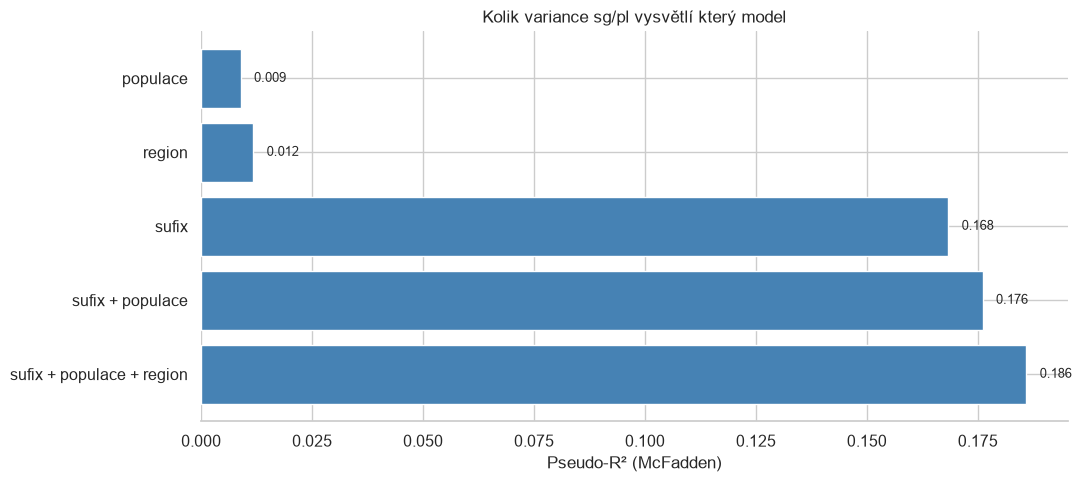

In [5]:
models = viz.fit_nested_logit_models(df)

fig = viz.plot_pseudo_r2_progression(models)
viz.save_fig(fig, "12_pseudo_r2_progression")

**Sufix samotný vysvětlí ~19× víc variance než populace samotná** (pseudo-R²
0.168 vs. 0.009) a ~14× víc než region samotný (0.012) — přímé potvrzení
závěru z nb11 v jednotném rámci, kde jsou všechny 3 prediktory měřené na
stejné škále (pseudo-R²), ne jen porovnávané přes nesouměřitelné p-values.

### Přidávají populace/region něco NAD RÁMEC sufixu?

Pseudo-R² roste přidáním jakékoli proměnné téměř vždy, i kdyby nic
neuměla — likelihood-ratio test řekne, jestli je ten nárůst víc, než by
se čekalo náhodou.

In [6]:
lr1 = viz.lr_test(models["sufix"], models["sufix + populace"])
print(f"sufix -> sufix+populace:          LR = {lr1['lr']:.2f}, df = {lr1['df']:.0f}, p = {lr1['p']:.4f}")

lr2 = viz.lr_test(models["sufix + populace"], models["sufix + populace + region"])
print(f"sufix+populace -> +region:        LR = {lr2['lr']:.2f}, df = {lr2['df']:.0f}, p = {lr2['p']:.4f}")

sufix -> sufix+populace:          LR = 10.36, df = 1, p = 0.0013
sufix+populace -> +region:        LR = 13.23, df = 3, p = 0.0042


Obojí je statisticky významné (p = 0.0013, resp. p = 0.0042) — populace i
region přidávají reálnou, ne jen náhodnou informaci nad rámec sufixu. Ale
přírůstek pseudo-R² je malý (0.168 → 0.176 → 0.186, dohromady +0.018) ve
srovnání s tím, co vysvětlí sufix samotný (0.168). **Sufix je hlavní
prediktor, populace a region jsou reálné, ale vedlejší doplňky.**

## 4. Finální model — koeficienty

Forest plot koeficientů (log-odds směrem k plurálu) finálního modelu
(sufix + populace + region), seřazeno dle velikosti efektu.

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1454: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1454: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:42: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:42: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=config.DPI_SAVE, bbox_inches="tight")


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1642
Model:                          Logit   Df Residuals:                     1635
Method:                           MLE   Df Model:                            6
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                  0.1859
Time:                        15:34:29   Log-Likelihood:                -545.90
converged:                       True   LL-Null:                       -670.59
Covariance Type:            nonrobust   LLR p-value:                 5.560e-51
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     4.1297      0.521      7.932      0.000       3.109       5.150
C(suffix_group)[T.nice]      -1.3689      0.160     -8.568      0.000      -1.682     

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  func(*args, **kwargs)


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


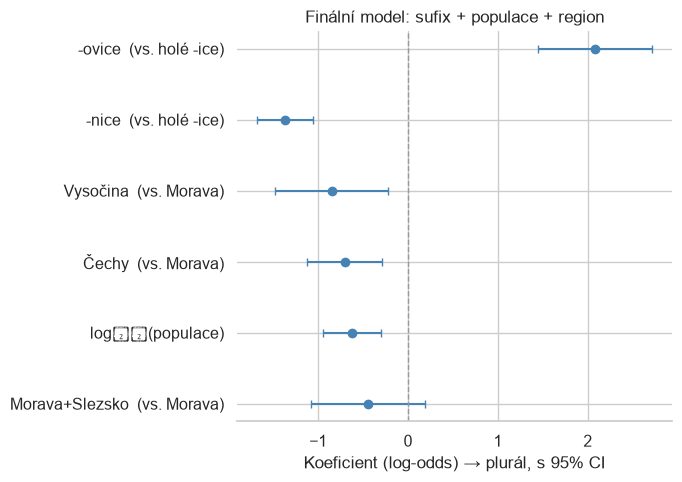

In [7]:
fig = viz.plot_model_coefficients(models["sufix + populace + region"])
viz.save_fig(fig, "12_model_coefficients")

print(models["sufix + populace + region"].summary())

Vzestupně dle velikosti (absolutní log-odds): `-ovice` (+2.08, vs. holé
-ice) je zdaleka nejsilnější koeficient v celém modelu — víc než 3×
větší než cokoli jiného. `-nice` (-1.37) táhne opačným směrem. Populace
(-0.62) a region (Vysočina -0.85, Čechy -0.71, Morava+Slezsko -0.45
nevýznamné) jsou menší, ale ne triviální — zhruba na stejné škále jako
regionální efekty z nb07/nb08, jen teď měřené *společně* se sufixem, ne
samostatně.

## 5. Shrnutí — a shrnutí celého projektu

**nb12 v kostce:** sufix je hlavní prediktor gramatického čísla (pseudo-R²
0.168 samotný, vs. 0.009 populace a 0.012 region), ale populace a region
přidávají statisticky prokazatelnou (byť malou) informaci navíc — LR testy
obě významné. Výjimky (2 typy — `-ovice` protipříklady bez zjevného
vzorce, `-šnice`/`Olešnice` jako opakující se lexikální kořen) ukazují dva
odlišné lingvistické mechanismy za stejným statistickým pozorováním.

**Celý projekt (nb07–nb12), jednou větou:** gramatické číslo obcí na
`-ice` není náhodné — je to primárně otázka **slovotvorby** (`-ovice`
formant, p≈10⁻⁵⁰), sekundárně **geografie** (Morava vs. Čechy, nb08
prostorová segregace) a jen okrajově **demografie** (populace, nb09), s
tím, že demografický/geografický signál z části, ale ne úplně, splývá
s tím, které sufixy jsou kde běžné (nb10, nb12 sekce 3).

**Pro článek:** tenhle notebook je dobrý uzávěr — dává číslo na "kolik
váží co" (pseudo-R² progrese) a dvě konkrétní, jmenovité výjimky jako
ilustrace. Doporučený pořadí vyprávění: 1) sufix (hlavní zjištění, nb11),
2) geografie (nb08, prostorová segregace singuláru), 3) demografie a
unknown (nb09-10, slabší/vedlejší efekty), 4) tahle syntéza jako uzávěr
s číslem, kolik čeho váží.